In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn import neighbors
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

In [2]:
import warnings
warnings.filterwarnings("ignore")

- Yfinance is the get the dataset of the stock
- KNN can implementation for both data Classification and regression


In [3]:
%pip install quandl
import quandl

Note: you may need to restart the kernel to use updated packages.


In [4]:

import yfinance as yf

# Tata Consumer Products Ltd. on NSE
data = yf.download("TATACONSUM.NS", start="2024-07-01", end="2025-07-01")
data.head(10)


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TATACONSUM.NS,TATACONSUM.NS,TATACONSUM.NS,TATACONSUM.NS,TATACONSUM.NS
Date,,,,,
2024-07-01,1086.497559,1089.376127,1079.995698,1082.080224,767705
2024-07-02,1096.870605,1101.833821,1072.054528,1087.936818,2026189
2024-07-03,1137.916382,1140.149829,1103.868797,1105.804402,4406793
2024-07-04,1126.848389,1146.304290,1124.962464,1139.107628,2113837
2024-07-05,1129.032349,1142.482591,1124.366853,1127.047062,1281630
2024-07-08,1142.333740,1155.436581,1127.642574,1129.627860,1958676
2024-07-09,1133.796875,1159.903436,1131.613109,1152.855695,1545936
2024-07-10,1142.333740,1148.239918,1121.686715,1133.796913,1015150


- Regression
- Close is a Target 
- Classification
- Buy is +1, Sell is -1 the Stock

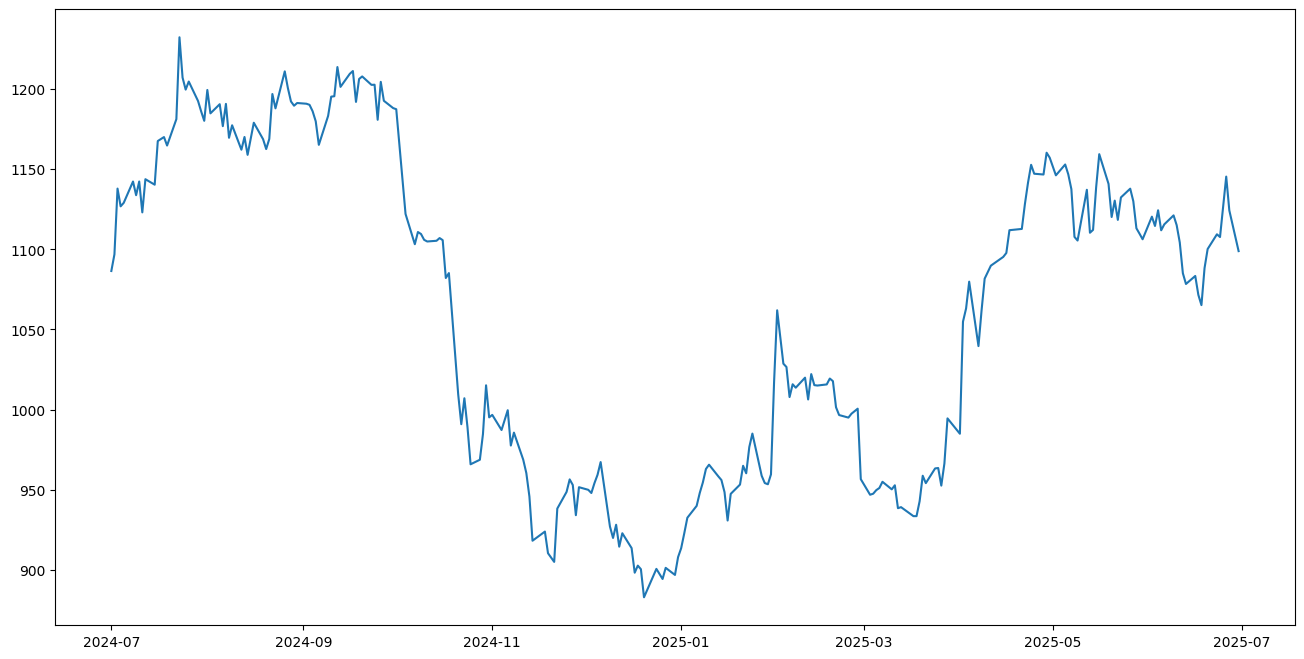

In [5]:
plt.figure(figsize=(16,8))
plt.plot(data['Close'], label ='Closing Price')

In [6]:
data['Open - Close'] = data['Open'] - data['Close']
data['High - Low'] = data['High'] - data['Low']
data = data.dropna()

Input Feature to Predict whether customer should Buy or Sell the Stock

In [7]:
X = data[['Open - Close','High - Low' ]]
X.head()

Price,Open - Close,High - Low
Ticker,,
Date,,
2024-07-01,-4.417335,9.380429
2024-07-02,-8.933788,29.779292
2024-07-03,-32.111980,36.281032
2024-07-04,12.259239,21.341826
2024-07-05,-1.985286,18.115738


Intention is to store +1 for the busy singal and -1 for the sell singal.The Target variable is 'Y' for Classificatoion

In [8]:
Y = np.where(data['Close'].shift(-1)>data['Close'], 1,-1)

In [9]:
Y

array([[ 1],
       [ 1],
       [-1],
       [ 1],
       [ 1],
       [-1],
       [ 1],
       [-1],
       [ 1],
       [-1],
       [ 1],
       [ 1],
       [-1],
       [ 1],
       [ 1],
       [-1],
       [-1],
       [ 1],
       [-1],
       [-1],
       [-1],
       [ 1],
       [-1],
       [ 1],
       [-1],
       [ 1],
       [-1],
       [ 1],
       [-1],
       [ 1],
       [-1],
       [ 1],
       [-1],
       [-1],
       [ 1],
       [ 1],
       [-1],
       [ 1],
       [-1],
       [-1],
       [-1],
       [ 1],
       [-1],
       [-1],
       [-1],
       [-1],
       [-1],
       [ 1],
       [ 1],
       [ 1],
       [ 1],
       [-1],
       [ 1],
       [ 1],
       [-1],
       [ 1],
       [ 1],
       [-1],
       [ 1],
       [-1],
       [ 1],
       [-1],
       [-1],
       [-1],
       [-1],
       [-1],
       [-1],
       [ 1],
       [-1],
       [-1],
       [-1],
       [ 1],
       [ 1],
       [-1],
       [-1],
       [ 1],
       [-1],

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3,random_state=42)

Implementation of KNN Classification

🔍 What is GridSearchCV?
- GridSearchCV is a hyperparameter tuning tool in scikit-learn.
- It helps you automatically find the best combination of parameters for a machine learning model by doing:

1 Exhaustive search over a grid of parameter values.

2 Using cross-validation to evaluate model performance for each combination.

- Because most models (like RandomForest, SVM, KNN, etc.) depend on hyperparameters (like n_estimators, C, max_depth) that can drastically affect accuracy.
- You could guess, but GridSearchCV helps you try all reasonable combinations and select the best.

In [11]:
#using gridsearch to find the best parameter
params = {'n_neighbors':[2,3,4,5,6,7,8,9,10,11,12,13,14,15]}
knn = neighbors.KNeighborsClassifier()
model = GridSearchCV(knn, params,cv=5)

#fit the model
model.fit(X_train,Y_train)

#Accuracy Score
accuracy_train = accuracy_score(Y_train,model.predict(X_train))
accuracy_test = accuracy_score(Y_test, model.predict(X_test))

print('Train_data Accuracy: %.2f', accuracy_train)
print('Test_data Accuracy:%.2f', accuracy_test)

Train_data Accuracy: %.2f 0.7988505747126436
Test_data Accuracy:%.2f 0.5066666666666667


In [12]:
predication_classification = model.predict(X_test)

- I used .ravel() (or .flatten()) to convert a 2D array into a 1D array, because pandas.DataFrame() requires each column to be 1D — and that’s what’s causing your error.



In [13]:
print("Y_test shape:", Y_test.shape)
print("predication_classification shape:", predication_classification.shape)
import numpy as np
import pandas as pd

actual_predicted_data = pd.DataFrame({
    'Actual Close': np.ravel(Y_test),
    'Predicted Close Value': np.ravel(predication_classification)
})


Y_test shape: (75, 1)
predication_classification shape: (75,)


In [14]:
actual_predicted_data.head(10)

,Actual Close,Predicted Close Value
0,1,-1
1,1,1
2,-1,-1
3,1,1
4,-1,-1
5,1,-1
6,1,-1
7,1,-1
8,-1,-1
9,-1,-1


- Regresssion Problem : KNN

In [15]:
Y = data['Close']

Implementation of KNN Regression

In [16]:
X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(X,Y, test_size=0.3,random_state=42)

#using the gridsearch to find best parameter
params = {'n_neighbors': [2,3,4,5,6,7,8,9,10,11,12,13,14,15]}
knn_reg = neighbors.KNeighborsRegressor()
model_reg = GridSearchCV(knn_reg,params, cv=5)

#fit the model and make prediction
model_reg.fit(X_train_reg,Y_train_reg)
prediction = model_reg.predict(X_test_reg)

In [17]:
print(prediction)

[[1043.90087455]
 [1043.18515015]
 [1063.55562483]
 [1043.90087455]
 [1016.63672747]
 [1053.12067086]
 [1063.72269113]
 [1035.75219727]
 [1110.71258545]
 [1103.56556048]
 [1070.51594761]
 [1044.19042533]
 [1036.74482509]
 [1111.85799735]
 [1055.56088693]
 [1010.76069423]
 [1087.88013131]
 [1079.05381557]
 [1042.77236503]
 [1079.05381557]
 [1109.06079973]
 [1090.46333095]
 [1062.08942958]
 [1031.61881365]
 [1090.59925188]
 [1038.44648525]
 [1043.18515015]
 [1090.83030483]
 [1007.20661272]
 [ 998.26218523]
 [1109.49547468]
 [1043.18515015]
 [1031.1260376 ]
 [1076.01980591]
 [1072.84391567]
 [1081.50626918]
 [1045.68710763]
 [1043.90087455]
 [1017.68963623]
 [1050.09415545]
 [1090.35067749]
 [1070.51594761]
 [1068.52357265]
 [1039.45868356]
 [1135.83173479]
 [1037.08478219]
 [1097.89356341]
 [1077.39004081]
 [1044.36160714]
 [1126.69594901]
 [1082.33197021]
 [1051.13340105]
 [1111.56367711]
 [1046.07759748]
 [1058.4553397 ]
 [1043.18515015]
 [1079.05381557]
 [1086.05722046]
 [1041.5882786

In [18]:
rms = np.sqrt(np.mean(np.power((np.array(Y_test)-np.array(prediction)),2)))

In [19]:
valid = pd.DataFrame({
    'Actual Close': np.ravel(Y_test_reg),
    'Prediction Close value': np.ravel(prediction)
})

In [20]:
valid.head(10)

,Actual Close,Prediction Close value
0,930.801453,1043.900875
1,1133.796875,1043.185150
2,910.402649,1063.555625
3,1180.848267,1043.900875
4,928.170959,1016.636727
5,942.862061,1053.120671
6,1095.282471,1063.722691
7,963.310547,1035.752197
8,1143.773071,1110.712585
9,951.597351,1103.565560
